In [19]:
import os
import math
from utils import *

import pennylane as qml
from pennylane import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

SEED = 42

# Generating the dataset

We will generate a synthetic dataset, generated by solving the Lorentz system using the Euler method. The Lorenz equations are defined as:

$$
\dot{x} = \sigma (y-x)
$$
$$
\dot{y} = -y -zx + \rho x
$$
$$
\dot{z} = -\beta z +xy
$$

where $(x, y, z)$ are the variables and $(\sigma , \rho , \beta)$ are parameters. 

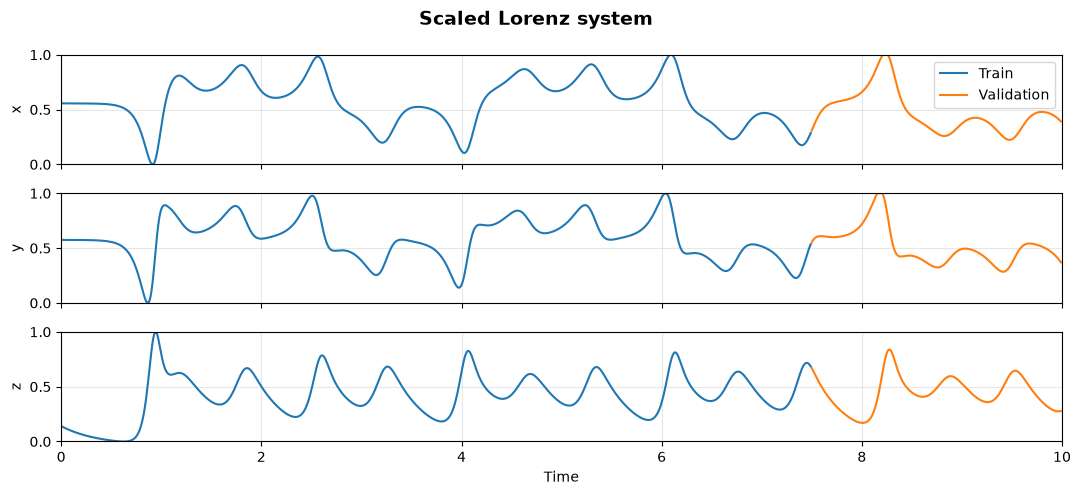

In [3]:
npoints = 1000
h = 0.01
params = [10, 28, 8 / 3]
init_point = [0, -0.01, 9]

dataset = generate_lorenz(
    npoints, 
    h,
    params, 
    init_point
)

# Trin test split
dataset_train, dataset_val = train_test_split(
    dataset,
    test_size=0.25,
    shuffle=False
)
time = np.arange(npoints) * h

time_tr = time[:len(dataset_train)]
time_val = time[len(dataset_train):]

# Scale the data to the range [0, 1]
scaler = MinMaxScaler()
train_scaled = scaler.fit_transform(dataset_train)
val_scaled = scaler.transform(dataset_val)
val_scaled = np.clip(val_scaled, 0, 1)

plot_lorenz(train_scaled, val_scaled, time_tr, time_val)

# iTransformer

The iTransformer encondes each variable as a token $X_{:,c}\in \mathbb{R}^T$, transposing the tokenization mechanism of the stardard Transformer. This architecture replaces traditional positional encodings by modeling temporal patterns through shared, token-independent feed-forward networks, while using an attention mechanism to capture inter-variable dependencies. This yields a more intuitive representation of multivariate time series data. The forecasting pipeline is given by:

$$
X'_{:,c}=LN(X_{:,c})
$$

$$
h_c^0 = \phi_{token}(X'_{:,c})
$$

$$
H^{l+1} = \text{TrmBlock}(H^l), \quad l = 0,..., L-1
$$

$$
Y'_{:,c} = \phi_{proj}(h_c^L)
$$

$$
\hat{Y}_{:,c} = LN^{-1}(Y'_{:,c})
$$

where $H^l = [h_1^l;...;h_C^l]\in \mathbb{R}^{C\times D}$ is the matrix of $C$ variate tokens at layer $l$, and $\phi_{token}:\mathbb{R}^T \rightarrow \mathbb{R}^D$ and $\phi_{proj}:\mathbb{R}^D \rightarrow \mathbb{R}^S$ are single layer linear mappings acting along the temporal dimension, with $D$ the token dimension. $LN$ denotes layer normalization that is applied independently to each variate token:

$$
LN(h_c) = \frac{h_c-\mu (h_c)}{\sqrt{\sigma^2 (h_c) + \epsilon}}, \quad c=1,...,C
$$

where $\mu(h_c)$ and $\sigma^2(h_c)$ denote the mean and variance of the $T-dimensional features and $LN^{-1}(\cdot)$ denotes the denormalization operator.

Each Transformer block combines single-head self-attention across variates with a position-wise feed-forward network. With residual conections and post-normalization, the update is:

$$
\tilde{H}^l = H^l + \text{SelfAttn}(\text{LN}'(H^l))
$$
$$
\tilde{H}^{l+1} = \tilde{H}^l  + \text{FFN}(\text{LN}'(\tilde{H}^l))
$$

where $LN'(\cdot)$ referts to the same standard layer normalization introduced before, with the difference that it operates along the channel dimension $C$.

Within the self-attention layer, the queries keys and values are obtained via linear projections:

$$
Q = H^lW_Q, \quad K = H^lW_K, \quad V = H^lW_V
$$

with $W_Q, W_K, W_V \in \mathbb{R}^{D\times d_k}$, where $d_k = D/M$ denotes the projected dimension. Since iTransformer employs a single-head attention mechanism, then $M=1$ and $d_k=D$. The attention weights are computed as:

$$
A = \text{Softmax}\left (\frac{QK^T}{\sqrt{d_k}} \right ) \in \mathbb{R}^{C\times C}
$$

and the attention output is:

$$
\text{SelfAttn}(H^l) = AV \in \mathbb{R}^{C \times d_k}
$$

The feed-forward network acts independently on each variate token and its given by:

$$
FFN(h) = W_2 ReLU(W_1h+b_1)+b_2, \quad h\in\mathbb{R}^D
$$

The first affine layer expands the token from $\mathbb{R}^D$ to $\mathbb{R}^{D_{ff}}$, where $D_{ff}$ is the internal dimension of the $FFN$, and the second layer projects it back to $\mathbb{R}^D$.

Given all of this, the iTransformer can capture multivariate relationships and is well suited for our forecasting problem.

In [ ]:
# Params
batch_size = 128 
n_chanels = 3
window_size = 5
batch_size = 128
horizon = 1
n_trfm_blocks = 2 
embding_dim = 9
ff_dim = 12

# Training hyperparameters
epochs = 50
lr = 5e-4

In [ ]:
# Create the sequences
x_tr, hor_tr = create_sequences(train_scaled, window_size, horizon)
x_val, hor_val = create_sequences(val_scaled, window_size, horizon)

# Convert to tensor
x_tr = torch.from_numpy(x_tr).double()
hor_tr = torch.from_numpy(hor_tr).double()

x_val = torch.from_numpy(x_val).double()
hor_val = torch.from_numpy(hor_val).double()

# Create the data loader
tr_dataset = TensorDataset(x_tr, hor_tr)
tr_loader = DataLoader(tr_dataset, batch_size=batch_size, shuffle=False)

In [ ]:
class ClassicalSelfAttention(nn.Module):
    def __init__(self,
                embding_dim
        ):
        super().__init__()
        self.dk = embding_dim 

        self.Wq = nn.Linear(embding_dim, self.dk)
        self.Wk = nn.Linear(embding_dim, self.dk)
        self.Wv = nn.Linear(embding_dim, self.dk)


    def forward(self, x):
        # x: (B, C, D)
        Q = self.Wq(x)
        K = self.Wk(x)
        V = self.Wv(x)

        # (B, C, D) @ (B, D, C) -> (B, C, C)
        attention_weights = Q @ K.transpose(1, 2) / math.sqrt(self.dk)

        # SoftMax in last dim (keys)
        attention_weights = torch.softmax(attention_weights, dim=-1)

        # (B, C, C) @ (B, C, D) -> (B, C, D)
        output = attention_weights @ V

        return output


class TransformerBlock(nn.Module):
    def __init__(self,
                embding_dim,
                ff_dim,
                eps=1e-5
        ):
        super().__init__()

        self.eps = eps

        self.self_att = ClassicalSelfAttention(embding_dim)

        self.feedforward = nn.Sequential(
            nn.Linear(embding_dim, ff_dim),
            nn.ReLU(),
            nn.Linear(ff_dim, embding_dim)
        )

    def normalize(self, x):
        # x: (B, C, D)
        mean = x.mean(dim=1, keepdim=True)
        var = x.var(dim=1, keepdim=True, unbiased=False)
        std = torch.sqrt(var + self.eps)

        x_normalized = (x - mean) / std

        return x_normalized

    def forward(self, x):
        x = x + self.self_att(self.normalize(x))
        x = x + self.feedforward(self.normalize(x))
        return x


class iTransformer_Model(nn.Module):
    def __init__(self, 
                window_size, 
                horizon, 
                n_trfm_blocks,
                embding_dim,
                ff_dim,
                eps=1e-5
        ):
        super().__init__()

        self.eps = eps

        self.token_embedding = nn.Linear(
            window_size, 
            embding_dim
        )

        self.trfm_blocks = nn.ModuleList([
            TransformerBlock(embding_dim, ff_dim)
            for _ in range(n_trfm_blocks)
        ])

        self.output_projection = nn.Linear(
            embding_dim, 
            horizon
        )

    def normalize(self, x):
        mean = x.mean(dim=2, keepdim=True)
        var = x.var(dim=2, keepdim=True, unbiased=False)
        std = torch.sqrt(var + self.eps)

        x_normalized = (x - mean) / std

        return x_normalized, mean, std

    def denormalize(self, x, mean, std):
        return x * std + mean
    

    def forward(self, x):
        # x.shape = (batch, window_size, chanels)

        x = x.transpose(1, 2) # (batch, chanels, window_size)

        x, mean, std = self.normalize(x)

        x = self.token_embedding(x) # (batch, chanels, embding_dim) 

        for block in self.trfm_blocks:
            x = block(x)

        x = self.output_projection(x) # (batch, chanels, horizon) 

        x = self.denormalize(x, mean, std)

        x = x.transpose(1, 2) # (batch, horizon, chanels) 

        return x